# CS 7830 Machine Learning
## Spring 26
Dennis Guhl

__________________________________________________________________________________

## 01_cae_v2

base model --> tanh output function, early stopping, lr scheduler, validation dataset determines threshold
__________________________________________________________________________________

## Preamble

In [1]:
import os
import numpy as np
import rasterio
import scipy.ndimage as ndimage
import random

# torch
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

# scheduler
import torch.optim.lr_scheduler as lr_scheduler

# data augmentation
from torchvision.transforms.v2 import Compose, RandomHorizontalFlip, RandomVerticalFlip, RandomRotation

# metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

#viz
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(42)
torch.manual_seed(42)

## CAE layer parameters algorithms

### Notes on CAE and helper for layer calculations for conv2d and convtranspose2d

https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html

encoder: floor((input - kernel) / stride) + 1

decoder: (input - 1) \* stride - 2\*padding + dilation\*kernel_size + output_padding

stride and dilation default to 1

floor((input - kernel) / stride) + 1


In [2]:
# # input worksheet conv2d

# input = 30
# kernel = 3
# stride = 2
# int((input - kernel)/stride) + 1

In [3]:
# # output worksheet convtranspose2d

# # paddings must be smaller than stride
# # (input - 1) \* stride - 2\*padding + dilation\*kernel_size + output_padding
# input = 249
# kernel = 3
# stride = 2
# padding = 0
# output_padding = 1
# dilation = 1

# ((input -1)* stride) - (2*padding) + (dilation*kernel) + output_padding

## CAE Class

In [4]:
class AutoCNN(nn.Module):
    def __init__(self):
        super(AutoCNN, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 2, kernel_size = 3, stride = 2), # 1000 -> 499
            nn.ReLU(),
            nn.Conv2d(2, 4, kernel_size = 3, stride = 2), # 249 
            nn.ReLU(),
            nn.Conv2d(4, 8, kernel_size = 3, stride = 2), # 124
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size = 3, stride = 2), # 61
            nn.ReLU(),
        )

        # Conv bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 4, kernel_size = 3, stride = 2), # 30
            nn.ReLU(),
        )

        #
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, kernel_size = 3, stride = 2), # 61
            nn.ReLU(),
            nn.ConvTranspose2d(16, 12, kernel_size = 3, stride = 2, output_padding=1), #124
            nn.ReLU(),
            nn.ConvTranspose2d(12, 8, kernel_size = 3, stride = 2, output_padding=0), #249
            nn.ReLU(),
            nn.ConvTranspose2d(8, 4, kernel_size = 3, stride = 2, output_padding=0),#499
            nn.ReLU(),
            nn.ConvTranspose2d(4, 1, kernel_size = 3, stride = 2, output_padding=1), #1000
            nn.Tanh()
        ) 

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x

## Dataset Loading Class and Notes

In [5]:
# https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html
# powershell extract zip: Get-ChildItem -Filter *.zip | ForEach-Object { Expand-Archive -LiteralPath $_.FullName -DestinationPath ($_.FullName -replace '\.zip$','') -Force }

class TifData(Dataset):
    def __init__(self, folderpath = "./", transform = None):
        self.path = folderpath
        self.transform = transform
        self.file_list = self.create_dem_list()

    def create_dem_list(self):
        seen = set()      
        dems = []    

        for dirpath, dirnames, filenames in os.walk(self.path):
            for f in filenames:
                if not f.lower().endswith(".tif"):
                    continue

                # dedupe by f
                if f in seen:
                    continue

                full = os.path.join(dirpath, f)

                # inspect the file for affine requirements
                try:
                    with rasterio.open(full) as src:
                        # Only pull the DEMS with the following signature
                        if (
                            # str(src.crs) == "EPSG:6551" # CRS 
                            src.res == (1.25, 1.25) # resolution 
                            and src.count == 1 # band
                        ):
                            seen.add(f) # add to this set
                            dems.append((full,f)) # append to list of tuples

                except:
                    pass

        return dems

    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        # load DEM files with rasterio
        with rasterio.open(self.file_list[idx][0]) as src:
            fname = self.file_list[idx][1]
            image = src.read()
        
        # as tensor
        image = torch.from_numpy(image).float()

        if self.transform:
            image = self.transform(image)

        #  zscore
        mean = image.mean()
        std = image.std()
        image = (image - mean) / (std + 1e-10)

        return image, fname
    


## Set Transforms, Load Dataset and Split it.
### assign model

In [6]:
# https://docs.pytorch.org/vision/stable/transforms.html

transform_train = Compose([
    RandomHorizontalFlip(p=0.5),
    RandomVerticalFlip(p=0.5)
])

dataset = TifData(folderpath="./training", transform=transform_train)


trainset, valset = torch.utils.data.random_split(dataset, (.8,.2))
print(f"trainset size is {len(trainset)}")
print(f"valset size is {len(valset)}")


loader = DataLoader(
    trainset,
    batch_size=8,
    shuffle = True,
    num_workers=0,
)

valoader = DataLoader(
    valset,
    batch_size =8,
    shuffle = False,
    num_workers = 0,
)

#assign model
model = AutoCNN()



trainset size is 180
valset size is 44


## Set Training Parameters and Loop


In [7]:

# epochs and lr and decayy vars
epochs = 100
lr = 1e-3
decay = 1e-5

#set early stopping vars
train_log = []
val_log = []
best_val = float('inf')
patience = 3
wait = 0


# loss
criterion = nn.MSELoss()

# optimizer
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=lr, # 
                             weight_decay=decay # L2
                             )

#define scheduler
scheduler = lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=25)

for epoch in range(epochs):
    ### training
    model.train()
    total = 0
    for image, _ in loader:
        optimizer.zero_grad()
        recon = model(image)
        loss = criterion(recon, image)
        loss.backward()
        optimizer.step()
        total += loss.item() #
    ### validation
    model.eval()
    total_val = 0
    with torch.no_grad():
        for image, _ in valoader:
            recon = model(image)
            vloss = criterion(recon, image)
            total_val += vloss.item()

    # epoch msg
    avg_train = total / len(loader)
    train_log.append(avg_train)
    avg_val = total_val / len(valoader)
    val_log.append(avg_val)
    # lr report and scheduler step
    reported_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    # report
    print(f"Epoch {epoch+1:3d}: train={avg_train:.5f} | val={avg_val:.5f} | lr={reported_lr:.5f}")

    # save weights on schedule
    if (epoch + 1) % 50 == 0:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
        }, f'checkpoint_epoch_{epoch+1}.pth ')
    
    #early stopping after possibly saving
    if avg_val < best_val:
        best_val = avg_val
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch   1: train=1.07499 | val=1.07155 | lr=0.00100
Epoch   2: train=1.06364 | val=1.06116 | lr=0.00096
Epoch   3: train=1.05421 | val=1.05213 | lr=0.00093
Epoch   4: train=1.04600 | val=1.04438 | lr=0.00089
Epoch   5: train=1.03882 | val=1.03747 | lr=0.00086
Epoch   6: train=1.03209 | val=1.02995 | lr=0.00082
Epoch   7: train=1.02304 | val=1.01688 | lr=0.00078
Epoch   8: train=0.97860 | val=0.87053 | lr=0.00075
Epoch   9: train=0.72394 | val=0.60972 | lr=0.00071
Epoch  10: train=0.55573 | val=0.50960 | lr=0.00068
Epoch  11: train=0.49203 | val=0.48565 | lr=0.00064
Epoch  12: train=0.47600 | val=0.47242 | lr=0.00060
Epoch  13: train=0.46214 | val=0.45884 | lr=0.00057
Epoch  14: train=0.45269 | val=0.44679 | lr=0.00053
Epoch  15: train=0.44637 | val=0.44323 | lr=0.00050
Epoch  16: train=0.43585 | val=0.43630 | lr=0.00046
Epoch  17: train=0.43278 | val=0.42887 | lr=0.00042
Epoch  18: train=0.42569 | val=0.42711 | lr=0.00039
Epoch  19: train=0.42091 | val=0.42332 | lr=0.00035
Epoch  20: t

## Loss Curve

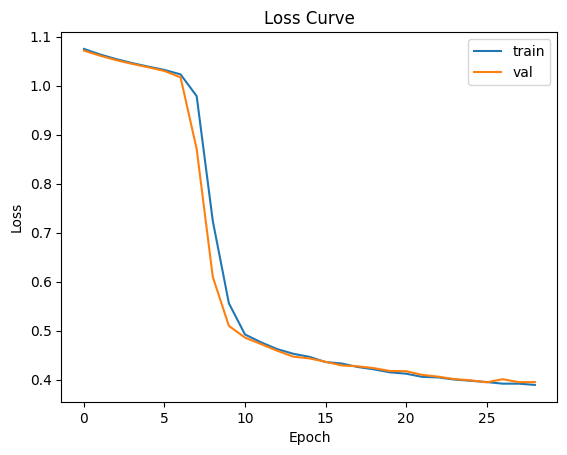

In [8]:
plt.plot(train_log, label='train')
plt.plot(val_log, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

## _________________________________________________


In [9]:
torch.save({
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss,
}, f'checkpoint_epoch_cae_v2_{epoch+1}.pth ')

## Load Saved Weights as Needed

In [10]:
# # https://docs.pytorch.org/docs/stable/generated/torch.load.html

# checkpoint = torch.load(r".\checkpoint_epoch_100.pth",
#     map_location=torch.device("cpu"),
#     weights_only=True,
# )
# model.load_state_dict(checkpoint['model_state_dict'])


## Validation Set 

use valset to establish thresholds without data leakage.


#### Switch model to eval mode and get results based on reconstruction error

First try to set threshold off validation set but validation set has no positive class in it. 

In [11]:
## notes: https://apxml.com/courses/autoencoders-representation-learning/chapter-7-applications-training-strategies/implementing-anomaly-detection-practice

# #eval mode
model.eval()
val_results = []

# get the error values
for image, fname in valset:
    with torch.no_grad():
        recon = model(image)
        error = criterion(recon, image)
        val_results.append((fname, error.item()))
# put images in order by error
val_results.sort(key=lambda x: x[1], reverse=True)

# show ranked order from highest reconstruction error to lowest for the test dataset
val_results

[('BN21450206.tif', 0.6670388579368591),
 ('BS14760440.tif', 0.5783369541168213),
 ('BN21280352.tif', 0.542080819606781),
 ('BN19560298.tif', 0.5228032469749451),
 ('BS18910768.tif', 0.49882543087005615),
 ('BN24270526.tif', 0.4781225025653839),
 ('BS24530755.tif', 0.4769028425216675),
 ('BN24660526.tif', 0.47423869371414185),
 ('BN19670261.tif', 0.4674752354621887),
 ('BS18980818.tif', 0.45696932077407837),
 ('BN24120528.tif', 0.4414574205875397),
 ('BS18270717.tif', 0.43007421493530273),
 ('BN23850497.tif', 0.4266946315765381),
 ('BN19610297.tif', 0.41084474325180054),
 ('BN20220216.tif', 0.41051632165908813),
 ('BS19180816.tif', 0.4046466052532196),
 ('BS19230810.tif', 0.39479151368141174),
 ('BS14980653.tif', 0.39060959219932556),
 ('BN22880410.tif', 0.3883873224258423),
 ('BS24550757.tif', 0.3852822780609131),
 ('BN23420302.tif', 0.3773820698261261),
 ('BN24650526.tif', 0.3762500286102295),
 ('BN19350257.tif', 0.36906880140304565),
 ('BS15450710.tif', 0.3615844249725342),
 ('BS243

In [12]:

val_errors = [slug[1] for slug in val_results]
threshold = np.percentile(val_errors, 90)
threshold

np.float64(0.49261455237865454)

In [13]:
val_mid = np.median(val_errors)
val_mid

np.float64(0.3726594150066376)

In [14]:
# 

# mean + k*sigma

m = np.mean(val_errors)
k = 2
sig = np.std(val_errors)

val_mid2 = m + (k*sig)
val_mid2

np.float64(0.5537370354567779)

## Test Set Evaluation

In [15]:
# This is a list of positive test files to check against

test_list = ['BS19810747.tif', 'BS19820746.tif', 'BS19810746.tif', 'BS19800738.tif', 
             'BS19820747.tif', 'BS19830747.tif', 'BS19830748.tif', 'BS19820748.tif', 
             'BS19860742.tif', 'BS19860743.tif', 'BS19870743.tif', 'BS19870742.tif', 
             'BS18320505.tif', 'BS18320503.tif', 'BS18330503.tif', 'BS18320502.tif', 
             'BS18310503.tif', 'BS18250501.tif', 'BS18260501.tif', 'BS18480473.tif', 
             'BS18500473.tif', 'BS18480472.tif', 'BS18500472.tif', 'BS18500471.tif', 
             'BS17980495.tif', 'BS17980496.tif', 'BS18000495.tif', 'BS18000496.tif', 
             'BS18010495.tif', 'BS18010496.tif', 'BS17630452.tif', 'BS17650452.tif', 
             'BS17620451.tif', 'BS17630451.tif', 'BS17650451.tif', 'BS17620450.tif', 
             'BS17630450.tif', 'BS17650450.tif'] # 38 tif files that have earthworks somewhere in them.

In [16]:

# Load the full test dataset from the designated folder
full_test_data = TifData(folderpath="./testing", transform=None)

# Check the length. It should be double the len of test_list
len(full_test_data), len(test_list)


(76, 38)

In [17]:

# #eval mode
model.eval()
results = []

# get the error values
for image, fname in full_test_data:
    with torch.no_grad():
        recon = model(image)
        error = criterion(recon, image)
        results.append((fname, error.item()))

# put images in order by error
results.sort(key=lambda x: x[1], reverse=True)

# show ranked order from highest reconstruction error to lowest for the test dataset
results


[('BS17980495.tif', 0.7729740738868713),
 ('BS18500471.tif', 0.702738881111145),
 ('BS19830748.tif', 0.6838436126708984),
 ('BS19820747.tif', 0.6836349964141846),
 ('BS18310503.tif', 0.6674373149871826),
 ('BS19180811.tif', 0.6303110122680664),
 ('BS17620450.tif', 0.6226969361305237),
 ('BS18250501.tif', 0.6202030777931213),
 ('BS18500473.tif', 0.6001051068305969),
 ('BS19810746.tif', 0.5864263772964478),
 ('BS18000495.tif', 0.5649852752685547),
 ('BS19870742.tif', 0.5389080047607422),
 ('BS18320502.tif', 0.5251805186271667),
 ('BS17630452.tif', 0.5212963223457336),
 ('BS17630450.tif', 0.5152537226676941),
 ('BS17630451.tif', 0.5094652771949768),
 ('BS17650450.tif', 0.5012234449386597),
 ('BS19150813.tif', 0.4886151850223541),
 ('BS19160816.tif', 0.4645423889160156),
 ('BS19170796.tif', 0.4645204544067383),
 ('BS19830747.tif', 0.4642716348171234),
 ('BS19820748.tif', 0.4622655510902405),
 ('BS18500472.tif', 0.459153413772583),
 ('BS14770440.tif', 0.45907822251319885),
 ('BS19870743.tif

In [18]:
# possible best threshold for test_list/compared to the val determiined threshold
np.median([slug[1] for slug in results]), val_mid, val_mid2

(np.float64(0.40534552931785583),
 np.float64(0.3726594150066376),
 np.float64(0.5537370354567779))

# Evaluate Metrics

In [19]:
### Avoiding data leakage by using validation set based threshold mean + k*sigma
y_true = [1 if slug[0] in test_list else 0 for slug in results] # in order of the previously sorted results

threshold = val_mid2 # recon error threshold
y_proba = [slug[1] for slug in results]  # list of recon errors
y_pred = [1 if slug > threshold else 0 for slug in y_proba]
# print the metrics and tweak
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


[[37  1]
 [28 10]]
              precision    recall  f1-score   support

           0       0.57      0.97      0.72        38
           1       0.91      0.26      0.41        38

    accuracy                           0.62        76
   macro avg       0.74      0.62      0.56        76
weighted avg       0.74      0.62      0.56        76



In [20]:
# # ADJUST THRESHOLD HERE
# y_true = [1 if slug[0] in test_list else 0 for slug in results] # in order of the previously sorted results

# threshold =  .05# recon error threshold
# y_proba = [slug[1] for slug in results]  # list of recon errors
# y_pred = [1 if slug > threshold else 0 for slug in y_proba]
# # print the metrics and tweak
# print(confusion_matrix(y_true, y_pred))
# print(classification_report(y_true, y_pred))


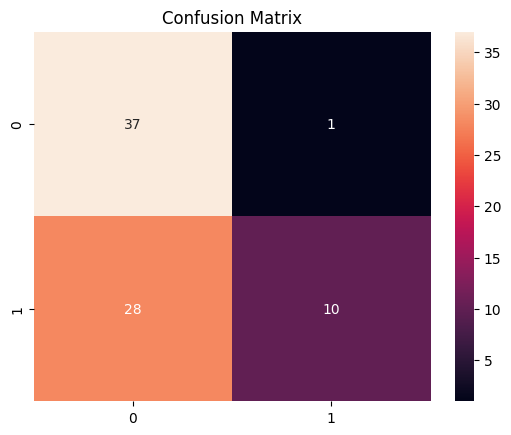

In [21]:
# quick hm

sns.heatmap(confusion_matrix(y_true, y_pred), annot = True)
plt.title("Confusion Matrix")
plt.show()

## Examine ROC, AUC

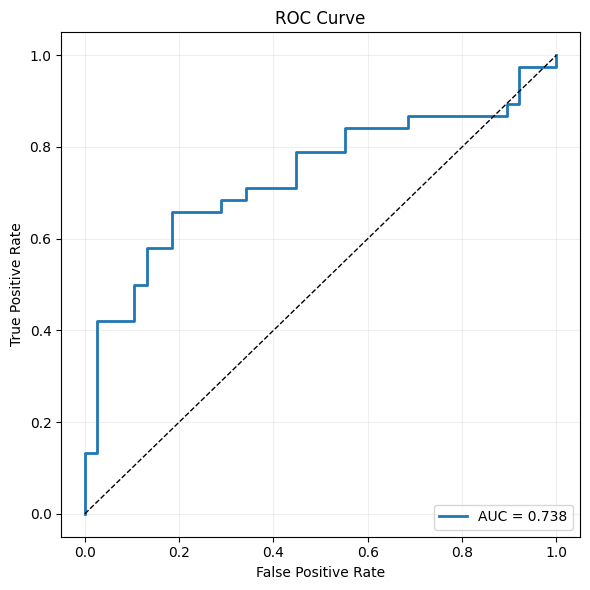

In [22]:
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
auc = roc_auc_score(y_true, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", linewidth=2)
plt.plot([0,1], [0,1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# END OF FILE